In [3]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

In [5]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

# Load data

In [7]:
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_daily_pr_202*',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr']

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [8]:
pr_def = xr.open_mfdataset('/scratch/m/m300948/def_100/pr/def_daily_pr_202*',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr']

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [11]:
# Find common times
common_times = np.intersect1d(pr_def.time.values, pr_ctl.time.values)
# Select only matching times in both datasets
pr_ctl_matched = pr_ctl.sel(time=common_times)
pr_def_matched = pr_def.sel(time=common_times)

In [13]:
pr_ctl = pr_ctl_matched
pr_def = pr_def_matched

# Masking

_Amazon basin masking_

In [14]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

In [15]:
ABinterp_biome = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)

In [16]:
pr_ctl_mask = pr_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [17]:
pr_def_mask = pr_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

# Converting into Hourly and Daily data

**Unit inversion - hour**

In [18]:
# masked - make 6 hourly data to daily data
pr_ctl_hour_mask = pr_ctl_mask.resample(time='H').mean()
pr_def_hour_mask = pr_def_mask.resample(time='H').mean()

In [19]:
# masked - make the unit into mm/hour
pr_ctl_mm_hour_mask = (pr_ctl_hour_mask*3600).compute()
pr_def_mm_hour_mask = (pr_def_hour_mask*3600).compute()

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/distributed/client.py:3106: UserWarning: Sending large graph of size 34.17 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


_check values frpm pr_ctl_mask, pr_ctl_mm_hour_mask, pr_ctl_mm_day_mask_

In [ ]:
# Iterate over each time step and plot the precipitation
for time_idx in range(len(pr_def_mm_hour_mask.sel(time='2020-02-06').time)):
    # Select the data for the current time step
    data = pr_def_mm_hour_mask.isel(time=time_idx)
    
    # Plot the data
   
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-85,-35,-20,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False
    
    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    m = ax.pcolormesh(lons,lats,data,cmap='Blues',vmin=0,vmax=100,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(0, 100, 11)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend='max',ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)

    plt.title(f'Hourly Precipitation at {str(data.time.values)}', fontsize='20')
    plt.show()

In [ ]:
# Iterate over each time step and plot the precipitation
for time_idx in range(len(pr_ctl_mm_hour_mask.sel(time='2021-12-03').time)):
    # Select the data for the current time step
    data = pr_def_mm_hour_mask.isel(time=time_idx)
    
    # Plot the data
   
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-85,-35,-20,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False
    
    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    m = ax.pcolormesh(lons,lats,data,cmap='Blues',vmin=0,vmax=100,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(0, 100, 11)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend='max',ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)

    plt.title(f'Hourly Precipitation at {str(data.time.values)}', fontsize='20')
    plt.show()

# PDF

In [30]:
xarray_names = ['pr_ctl_mm_hour_mask','pr_def_mm_hour_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

_hour_

In [28]:
condition_def = pr_def_mm_hour_mask_f > 50 # ctl_hour_q99
count_above_threshold_def = np.sum(condition_def)
print(count_above_threshold_def/len(pr_def_mm_hour_mask_f)*100, count_above_threshold_def)

0.0230893615001534 317445


In [30]:
condition_ctl = pr_ctl_mm_hour_mask_f > 50
count_above_threshold_ctl = np.sum(condition_ctl)
print(count_above_threshold_ctl/len(pr_ctl_mm_hour_mask_f)*100, count_above_threshold_ctl)

0.014935201396347016 202854


### 1) division in each year

In [32]:
# ctl hourly data
pr_ctl_mm_hour_mask_2020 = pr_ctl_mm_hour_mask.sel(time=slice('2020-01-01','2020-12-31'))
pr_ctl_mm_hour_mask_2021 = pr_ctl_mm_hour_mask.sel(time=slice('2021-01-01','2021-12-31'))
pr_ctl_mm_hour_mask_2022 = pr_ctl_mm_hour_mask.sel(time=slice('2022-01-01','2022-12-31'))

In [33]:
# DEF hourly data
pr_def_mm_hour_mask_2020 = pr_def_mm_hour_mask.sel(time=slice('2020-01-01','2020-12-31'))
pr_def_mm_hour_mask_2021 = pr_def_mm_hour_mask.sel(time=slice('2021-01-01','2021-12-31'))
pr_def_mm_hour_mask_2022 = pr_def_mm_hour_mask.sel(time=slice('2022-01-01','2022-12-31'))

In [34]:
# years
new_suffix = '_f'

xarray_names = ['pr_ctl_mm_hour_mask_2020','pr_ctl_mm_hour_mask_2021','pr_ctl_mm_hour_mask_2022',
                'pr_def_mm_hour_mask_2020','pr_def_mm_hour_mask_2021','pr_def_mm_hour_mask_2022']

for name in xarray_names:
    dset_name = name 
    xarray_data = globals()[dset_name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = dset_name + new_suffix
    globals()[new_name] = xarray_data_f

/tmp/ipykernel_3397666/701508835.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('PiYG')


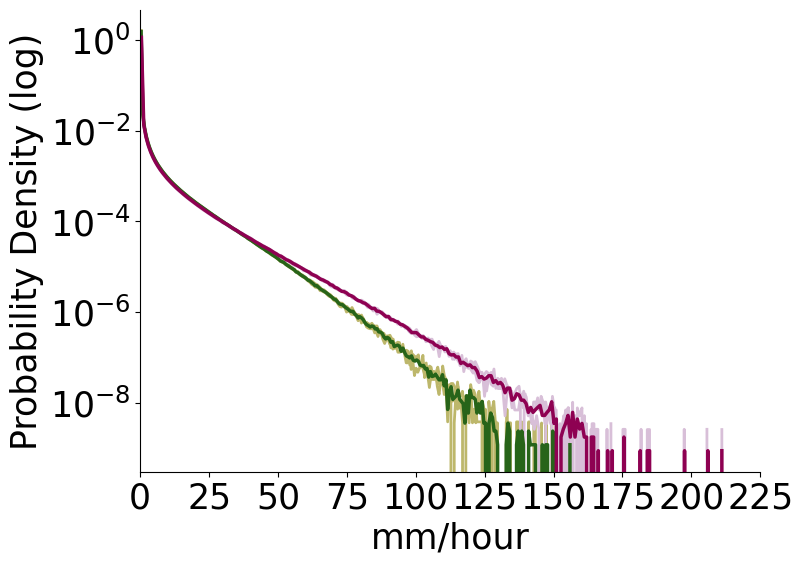

In [35]:
# Normalize the PDF
pdf_ctl_2020, bins_ctl_2020 = np.histogram(pr_ctl_mm_hour_mask_2020_f, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_2020, bins_def_2020 = np.histogram(pr_def_mm_hour_mask_2020_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_2021, bins_ctl_2021 = np.histogram(pr_ctl_mm_hour_mask_2021_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_def_2021, bins_def_2021 = np.histogram(pr_def_mm_hour_mask_2021_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl_2022, bins_ctl_2022 = np.histogram(pr_ctl_mm_hour_mask_2022_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_def_2022, bins_def_2022 = np.histogram(pr_def_mm_hour_mask_2022_f, bins=250, density=True)  # Adjust the number of bins as needed
pdf_ctl, bin_edges_ctl = np.histogram(pr_ctl_mm_hour_mask_f, bins=250, density=True)
pdf_def, bin_edges_def = np.histogram(pr_def_mm_hour_mask_f, bins=250, density=True)

# Calculate the bin centers
bin_centers_ctl_2020 = (bins_ctl_2020[:-1] + bins_ctl_2020[1:]) * 0.5
bin_centers_def_2020 = (bins_def_2020[:-1] + bins_def_2020[1:]) * 0.5
bin_centers_ctl_2021 = (bins_ctl_2021[:-1] + bins_ctl_2021[1:]) * 0.5
bin_centers_def_2021 = (bins_def_2021[:-1] + bins_def_2021[1:]) * 0.5
bin_centers_ctl_2022 = (bins_ctl_2022[:-1] + bins_ctl_2022[1:]) * 0.5
bin_centers_def_2022 = (bins_def_2022[:-1] + bins_def_2022[1:]) * 0.5
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_2020, pdf_ctl_2020, label='CTL_2020', color=clr[0], linewidth=2)
plt.plot(bin_centers_ctl_2021, pdf_ctl_2021, label='CTL_2021', color=clr[1], linewidth=2)
plt.plot(bin_centers_ctl_2022, pdf_ctl_2022, label='CTL_2022', color=clr[2], linewidth=2)
plt.plot(bin_centers_def_2020, pdf_def_2020, label='DEF_2020', color=clr[3], linewidth=2)
plt.plot(bin_centers_def_2021, pdf_def_2021, label='DEF_2021', color=clr[4], linewidth=2)
plt.plot(bin_centers_def_2022, pdf_def_2022, label='DEF_2022', color=clr[5], linewidth=2)
plt.plot(bin_centers_ctl, pdf_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')

plt.xlim(0, 225)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

## Divison into four categories

In [59]:
import pandas as pd

In [36]:
# Hourly precipitation
xarray_names = ['pr_ctl_mm_hour','pr_def_mm_hour']
new_suffix = ['_norain','_light','_moderate','_heavy','_violent']

for name in xarray_names:
    for suffix in new_suffix:
        dsetname = name + '_mask_f'
        xarray_data = globals()[dsetname]
        if suffix == '_norain':
            xarray_data_f = xarray_data[xarray_data == 0]
        if suffix == '_light':
            xarray_data_f = xarray_data[(xarray_data > 0) & (xarray_data <= 2.5)]
        elif suffix == '_moderate':
            xarray_data_f = xarray_data[(xarray_data > 2.5) & (xarray_data <= 10)]
        elif suffix == '_heavy':
            xarray_data_f = xarray_data[(xarray_data > 10) & (xarray_data <= 50)]
        elif suffix == '_violent':
            xarray_data_f = xarray_data[xarray_data > 50]
        new_name = name + suffix
        globals()[new_name] = xarray_data_f

In [40]:
# hourly precipitation
import pandas as pd
df = pd.DataFrame({
    'Category': ['No_rain', 'Light', 'Moderate', 'Heavy', 'Violent'],
    'CTL': [len(pr_ctl_mm_hour_norain), len(pr_ctl_mm_hour_light), len(pr_ctl_mm_hour_moderate), len(pr_ctl_mm_hour_heavy), len(pr_ctl_mm_hour_violent)],
    'DEF': [len(pr_def_mm_hour_norain), len(pr_def_mm_hour_light), len(pr_def_mm_hour_moderate), len(pr_def_mm_hour_heavy), len(pr_def_mm_hour_violent)],
    'Difference': [(len(pr_def_mm_hour_norain)-len(pr_ctl_mm_hour_norain))/len(pr_ctl_mm_hour_norain) * 100, (len(pr_def_mm_hour_light)-len(pr_ctl_mm_hour_light))/len(pr_ctl_mm_hour_light) * 100, 
                   (len(pr_def_mm_hour_moderate)-len(pr_ctl_mm_hour_moderate))/len(pr_ctl_mm_hour_moderate) * 100, 
                   (len(pr_def_mm_hour_heavy)-len(pr_ctl_mm_hour_heavy))/len(pr_ctl_mm_hour_heavy) * 100, 
                   (len(pr_def_mm_hour_violent)-len(pr_ctl_mm_hour_violent))/len(pr_ctl_mm_hour_violent) * 100]
})

In [41]:
print(df)

   Category         CTL         DEF  Difference
0   No_rain       57640      157325  172.944136
1     Light  1316832426  1318861967    0.154123
2  Moderate    23258404    21488626   -7.609198
3     Heavy    10153480     9684898   -4.614989
4   Violent      202170      311304   53.981303


In [44]:
print(df['Difference'])

0    172.944136
1      0.154123
2     -7.609198
3     -4.614989
4     53.981303
Name: Difference, dtype: float64


In [29]:
print(df['CTL']/len(pr_ctl_mm_hour_mask_f)*100)
print(df['DEF']/len(pr_ctl_mm_hour_mask_f)*100)

0    0.004244
1    0.004244
2    1.722878
3    0.751619
4    0.014935
Name: CTL, dtype: float64
0    0.011583
1    0.011583
2    1.618409
3    0.729161
4    0.023390
Name: DEF, dtype: float64


In [ ]:
# Daily precipitation
df = pd.DataFrame({
    'Category': ['Light', 'Moderate', 'Heavy', '_veryheavy', 'Violent'],
    'CTL': [len(pr_ctl_light), len(pr_ctl_moderate), len(pr_ctl_heavy), len(pr_ctl_veryheavy), len(pr_ctl_violent)],
    'DEF': [len(pr_def_light), len(pr_def_moderate), len(pr_def_heavy), len(pr_def_veryheavy), len(pr_def_violent)],
    'Difference': [(len(pr_def_light)-len(pr_ctl_light))/len(pr_ctl_light) * 100, (len(pr_def_moderate)-len(pr_ctl_moderate))/len(pr_ctl_moderate) * 100, 
                   (len(pr_def_heavy)-len(pr_ctl_heavy))/len(pr_ctl_heavy) * 100, (len(pr_def_veryheavy)-len(pr_ctl_veryheavy))/len(pr_ctl_veryheavy) * 100, (len(pr_def_violent)-len(pr_ctl_violent))/len(pr_ctl_violent) * 100]
})

In [16]:
print(df['CTL']/len(pr_ctl_mm_day_mask_f)*100)
print(df['DEF']/len(pr_ctl_mm_day_mask_f)*100)

0    79.002260
1    13.372850
2     5.592697
3     0.648780
Name: CTL, dtype: float64
0    82.324362
1    11.513210
2     5.459309
3     1.037757
Name: DEF, dtype: float64


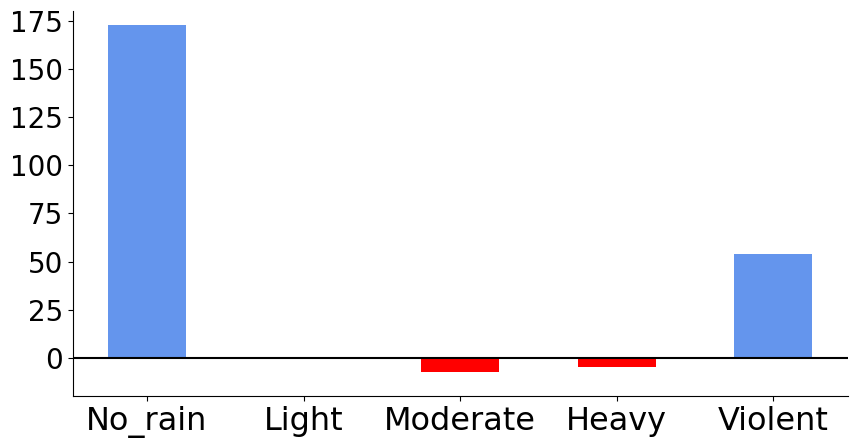

In [43]:
colors = ['cornflowerblue', 'cornflowerblue', 'red', 'red', 'cornflowerblue']

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df['Category'], df['Difference'], color=colors, width=0.5)
plt.axhline(y=0, color='black', linestyle='-')
plt.ylim(-20, 180)
plt.xticks(fontsize=23)
plt.yticks(fontsize=20)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)